# NX 465 Miniproject 2
By Tallulah Rytz and Noa Ette

## Dependencies

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve1d

## Exercise 0 — Ring attractors in 1D

In [3]:
def mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh):
    return A_exc * np.exp(-(x**2) / sigma_exc**2) - A_inh * np.exp(-(x**2) / sigma_inh**2)

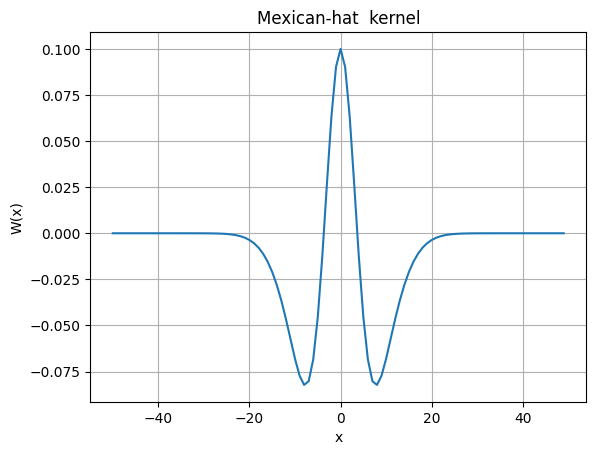

In [8]:
M = 100
x = np.linspace(-M / 2, M / 2, M, endpoint=False)
A_exc, sigma_exc = 0.3, 5.0
A_inh, sigma_inh = 0.2, 10.0
W = mexican_hat_1d(x, A_exc, sigma_exc, A_inh, sigma_inh)

fig, ax = plt.subplots()
ax.plot(x, W)
ax.set_xlabel("x")
ax.set_ylabel("W(x)")
ax.set_title("Mexican-hat  kernel")
ax.grid(True)
plt.show()

### Ex. 0.3 — Biology

The mexican-hat kernel is supposed to represent the fact that nearby neurons excite each other whilst neurons further away are inhibited. This means that local excitation can be amplified with longer range inhibition stabilizing the network.


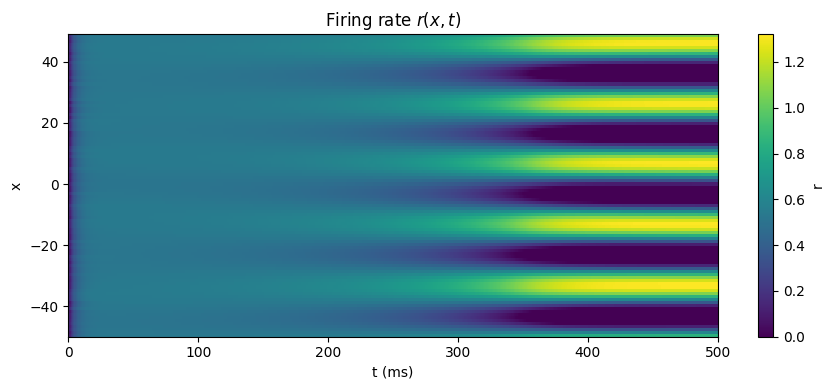

In [13]:
tau = 10.0 
dt = 1.0
T = 500
n_steps = int(T / dt)
B = 1.0

def run_ring_attractor(seed, M=M, W=W, tau=tau, dt=dt, n_steps=n_steps, B=B):
    rng = np.random.default_rng(seed)
    s = rng.uniform(0.0, 0.1, M)
    r_hist = np.empty((n_steps, M))
    for k in range(n_steps):
        r = np.maximum(0.0, s)
        r_hist[k] = r
        Irec = convolve1d(r, W, mode="wrap")
        s = s + dt * (-s + Irec + B) / tau
    return r_hist

r_hist = run_ring_attractor(67)

t_ms = np.arange(n_steps) * dt

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(
    r_hist.T,
    aspect="auto",
    origin="lower",
    extent=(0, T, x.min(), x.max()),
    interpolation="nearest",
)
ax.set_xlabel("t (ms)")
ax.set_ylabel("x")
ax.set_title(r"Firing rate $r(x,t)$")
plt.colorbar(im, ax=ax, label="r")
plt.tight_layout()
plt.show()

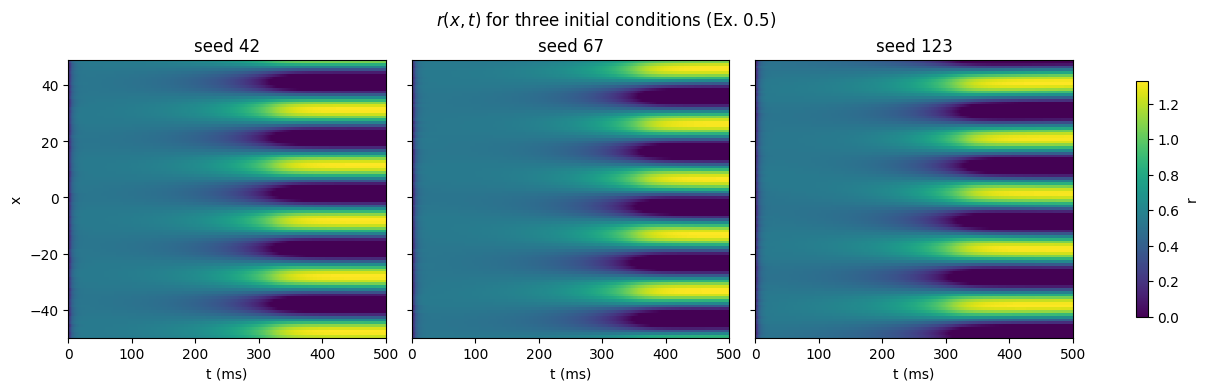

In [ ]:
seeds = [42, 67, 123]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True, constrained_layout=True)
im = None
for ax, seed in zip(axes, seeds):
    rh = run_ring_attractor(seed)
    im = ax.imshow(
        rh.T,
        aspect="auto",
        origin="lower",
        extent=(0, T, x.min(), x.max()),
        interpolation="nearest",
    )
    ax.set_xlabel("t (ms)")
    ax.set_title(f"seed {seed}")
axes[0].set_ylabel("x")
fig.suptitle(r"$r(x,t)$ for three different seeds")
fig.colorbar(im, ax=list(axes), shrink=0.85, label="r")
plt.show()

### Ex. 0.5 — Behavior and dependence on initialization

With the Mexican-hat weights on a **ring**, the network does not settle to uniform activity: recurrent excitation amplifies fluctuations while inhibition suppresses distant sites, so activity typically collapses to one or a few **localized bumps** (a **continuous attractor** / bump state). The **qualitative** behavior is **similar** across runs: we consistently see stable bumps after an initial transient. The **details** do depend on initialization: **where** the bump sits on the ring, how many bumps appear transiently, and the early trajectory differ across seeds because the ring has a **continuum** of equivalent bump positions. So: same type of attractor, not the same exact spatial pattern unless symmetry is broken.